# **Group06: Advertising Sales Prediction**

--------------------------------------------
## **Problem Statement**

Predict sales from advertising budgets (TV, Radio, Newspaper)

**Goal:** Find the best model for **Sales Prediction** by building different models and compare their performance. 

--------------------------------------------
Type of ML: Supervised Learning <br>
Sub-type: Regression  
Target (what we want to predict): Sales  
Features (inputs): TV, Radio, Newspaper


## **1. Understanding the Data**

In [295]:
# Import necessary libraries
import numpy as np
import pandas as pd

# for data Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns

In [296]:
data = pd.read_csv("../data/advertising.csv")
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [297]:
data.shape # check shape of the data (how many rows and columns)

(200, 4)

In [298]:
data.info() # check data_types of each column and if there are any missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [299]:
data.describe() # check the summary statistics

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## **Data Visualization (EDA)**

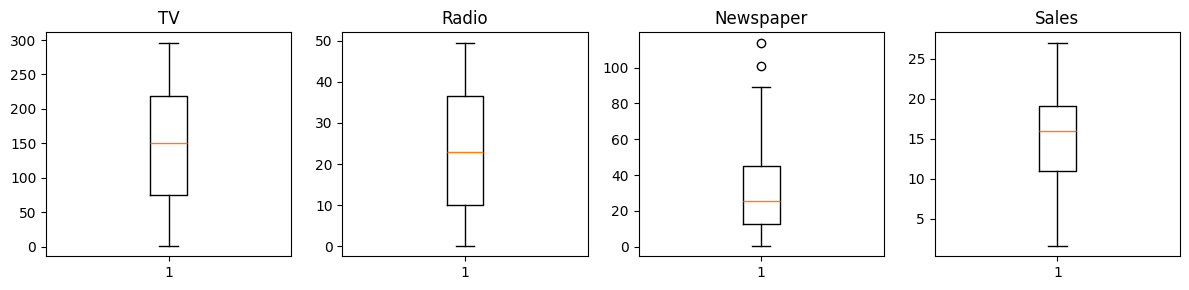

In [300]:
# plot the boxplot of the data , see outlier
fig, axs = plt.subplots(1, 4,figsize=(12, 3))
axs[0].boxplot(data['TV'])
axs[1].boxplot(data['Radio'])
axs[2].boxplot(data['Newspaper'])
axs[3].boxplot(data['Sales'])
axs[0].set_title('TV')
axs[1].set_title('Radio')
axs[2].set_title('Newspaper')
axs[3].set_title('Sales')
plt.tight_layout()
plt.show()

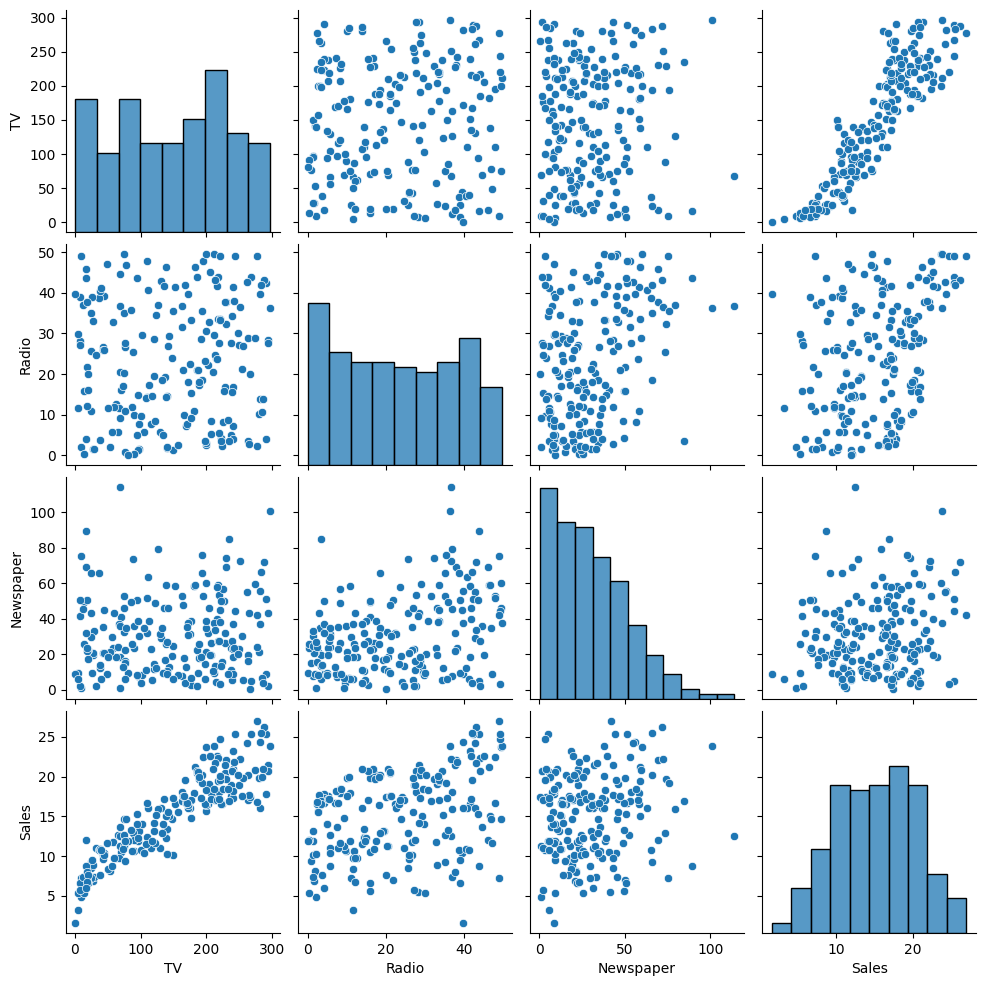

In [301]:
# Pairplot to see relationships, to see trends and distributions
sns.pairplot(data)

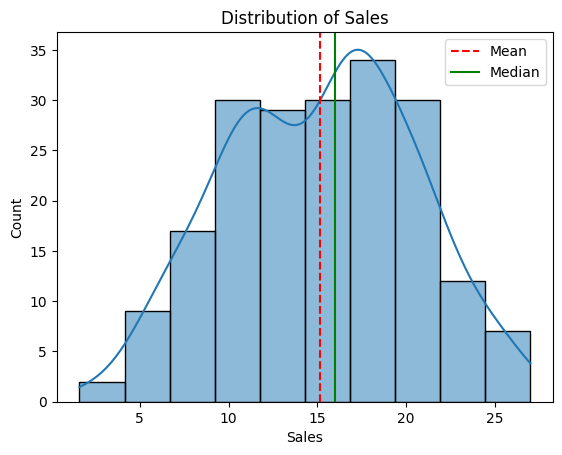


Sales Distribution Analysis:
Skewness: -0.07


In [302]:
# Visualize distributions, to see if there are any skewness
sns.histplot(data['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.axvline(data['Sales'].mean(), color='r', linestyle='--', label='Mean')
plt.axvline(data['Sales'].median(), color='g', linestyle='-', label='Median')
plt.legend()
plt.show()

# Print skewness interpretation
print("\nSales Distribution Analysis:")
skewness = data['Sales'].skew()
print(f"Skewness: {skewness:.2f}")

**Since the we see a little left skew(-0.07), it is still approximately normal distribution. So it is good for linear models**

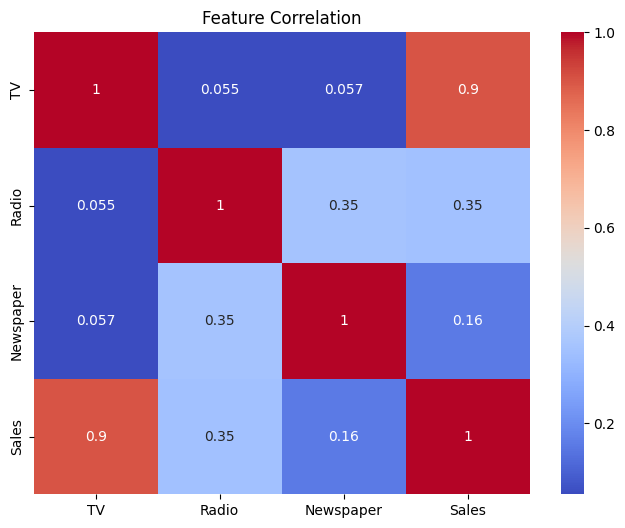

In [303]:
# Correlation heatmap, to see how features are correlated with each other
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

The correlation show that **TV and Radio are highly correlated with Sales**, while **Newspaper has a weaker correlation**

# **2. Data Preprocessing**

In [304]:
# Check for missing values
print(data.isnull().sum())

#handle missing values
#data = data.dropna()
data = data.fillna(data.mean()) 

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [305]:
from sklearn.model_selection import train_test_split

In [306]:
# get all features
X = data[['TV', 'Radio', 'Newspaper']] 
y = data['Sales'] # target column

# Split the data into 80% training and 20% testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

# **3. Model testing and building**

**- Use default parameters for all models.**  
**- Use all features with scaling data first.**  
**- Evaluate models on both train and test sets.**  
**- using pipelines** 

In [307]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [308]:
# test with 5 models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso()
}

**Model Evaluation (On both train and test set)**

In [309]:
from sklearn.metrics import mean_squared_error, r2_score

In [310]:
print("Model Evaluation Results:\n")
print(f"{'Model':<27} | {'Dataset':<8} | {'R²':<8} | {'RMSE':<8}")

for name, model in models.items():
    # Create a pipeline with scaling and model
    pipeline = make_pipeline(StandardScaler(), model)

    # Train the model ONCE
    pipeline.fit(X_train, y_train)

    # Predict and evaluate on Train set
    y_train_pred = pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # Predict and evaluate on Test set
    y_test_pred = pipeline.predict(X_test)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Output both results
    print(f"\n{name:<27} | {'Train':<8} | {r2_train:.4f} | {rmse_train:.4f}")
    print(f"{name:<27} | {'Test':<8} | {r2_test:.4f} | {rmse_test:.4f}")

Model Evaluation Results:

Model                       | Dataset  | R²       | RMSE    

Linear Regression           | Train    | 0.9001 | 1.6359
Linear Regression           | Test     | 0.9059 | 1.7052

Random Forest               | Train    | 0.9913 | 0.4822
Random Forest               | Test     | 0.9535 | 1.1987

Gradient Boosting           | Train    | 0.9932 | 0.4265
Gradient Boosting           | Test     | 0.9587 | 1.1293

Ridge Regression            | Train    | 0.9001 | 1.6362
Ridge Regression            | Test     | 0.9057 | 1.7074

Lasso Regression            | Train    | 0.8291 | 2.1402
Lasso Regression            | Test     | 0.8222 | 2.3439


# **4. Model improvment**

**- Feature selction (Use selected features with scaling data first.)**    
**- Evaluate models on both train and test sets for selected features**    
**- Cross validation**   
**- Find best parameters for the high performing model after cross validation results**  



<Axes: xlabel='Newspaper', ylabel='Sales'>

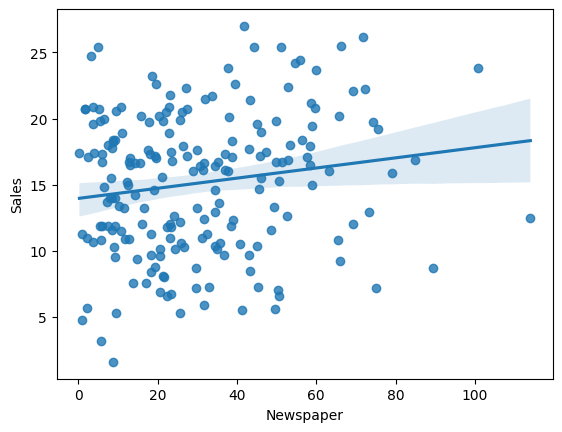

In [311]:
# Plotting the relationship between Newspaper and Sales
sns.regplot(x='Newspaper', y='Sales', data=data)

**As we see the plot, the Newspaper has a little relation to sale. So we decided  to cut it out and do feature engineering to create new features and final defining features in feature selection**

In [312]:
#feature engineering 
data['TV_Radio'] = data['TV'] * data['Radio']

#select features and target (drop newspaper and add one new columns)
X = data[['TV', 'Radio', 'TV_Radio']]  
y = data['Sales']

In [313]:
# Split the data into training and test sets using new features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [314]:
# Re-run the model evaluation loop using the new X, y
print("\nNew Model Evaluation Results with Selected Features:\n")
print(f"{'Model':<27} | {'Dataset':<8} | {'R²':<8} | {'RMSE':<8}")

for name, model in models.items():
    # Create a pipeline with scaling and the model
    pipeline = make_pipeline(StandardScaler(), model)

    # Train the model
    pipeline.fit(X_train, y_train)

    # Predict and evaluate on Train set
    y_train_pred = pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # Predict and evaluate on Test set
    y_test_pred = pipeline.predict(X_test)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Output both results
    print(f"\n{name:<27} | {'Train':<8} | {r2_train:.6f} | {rmse_train:.6f}")
    print(f"{name:<27} | {'Test':<8} | {r2_test:.6f} | {rmse_test:.6f}")


New Model Evaluation Results with Selected Features:

Model                       | Dataset  | R²       | RMSE    

Linear Regression           | Train    | 0.909814 | 1.554651
Linear Regression           | Test     | 0.924145 | 1.531018

Random Forest               | Train    | 0.993766 | 0.408747
Random Forest               | Test     | 0.963546 | 1.061355

Gradient Boosting           | Train    | 0.996805 | 0.292637
Gradient Boosting           | Test     | 0.964290 | 1.050471

Ridge Regression            | Train    | 0.909777 | 1.554965
Ridge Regression            | Test     | 0.924542 | 1.527000

Lasso Regression            | Train    | 0.860448 | 1.933883
Lasso Regression            | Test     | 0.870456 | 2.000763


**After cut a feature and add a new feature, we see our model is performing better.**  
=>  So we will use this selected features to continue building our model.   
=> from now on, we will not use our old feature selection method. We use the new  **selected features**

-------

* ## **Cross-Validation**
(cross validation is a method to evaluate the performance of a model on a dataset by splitting the dataset into k subsets, training the model on k-1 subsets, and testing it on the remaining subset. This process is repeated k times, with each subset serving as the test set once.)

In [315]:
from sklearn.model_selection import cross_val_score

In [316]:
# Evaluate each model using cross-validation
print("\nCross-Validation Results:\n")
print(f"{'Model':<27} | {'Mean R²':<8} | {'Mean RMSE':<8}")

for name, model in models.items():
    pipeline = make_pipeline(StandardScaler(), model)
    
    # Perform cross-validation
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')  # cv = 5 is the number of folds
    mean_r2 = scores.mean()
    
    # Calculate Mean RMSE
    rmse_scores = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    mean_rmse = rmse_scores.mean()

    # Output results
    print(f"{name:<27} | {mean_r2:.6f} | {mean_rmse:.6f}")


Cross-Validation Results:

Model                       | Mean R²  | Mean RMSE
Linear Regression           | 0.897716 | 1.564687
Random Forest               | 0.950143 | 1.092643
Gradient Boosting           | 0.944669 | 1.156945
Ridge Regression            | 0.897715 | 1.564398
Lasso Regression            | 0.840564 | 1.960595


After cross-validation, we decide to **pick the ones** that performed well.</br> => **Random Forest** with r2 = 0.95014 and rmse = 1.09 is defining as tunable model for **hyperparameter tuning**.

-----

* ## **Hyperparameter Tuning with GridSearchCV**

In the previous step, Random Forest Regressor model just applied cross-validation by cv=5 **using default hyperparameters**. </br>=> So we will try to find **the best hyperparameters of the model** to improve our model performance.

In [317]:
from sklearn.model_selection import GridSearchCV

In [318]:
#fine turn and best parameters
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("\nBest Random Forest Parameters:", grid_search.best_params_)
print("Best R² from CV:", grid_search.best_score_)


Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best R² from CV: 0.9509961566997124


------
All the results of doing **cross validation and hyperparameter tuning** was done only on **X_train and y_train**. But our **X_test** has never been seen by that model (random forest model that get after CV and hyperparameter tuning)
  
=> So we will use the final model to make predictions on **X_test** and **y_test** in order to evaluate the **final model's performance**.

-------
# **5. Final Model Evaluation**

**Train the final model with the best hyperparameters**

In [319]:
final_model = grid_search.best_estimator_
final_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Predict on test data to see how it improves**

In [320]:
y_pred = final_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Final Test R²: {r2:.7f}")
print(f"Final Test RMSE: {rmse:.7f}")

Final Test R²: 0.9636030
Final Test RMSE: 1.0605225


--------------------------------------------
**🔍 Result Analysis on Random Forest Regressor (Summary)**  

**Results of Cross Validation and Hyperparameter Tuning:**
* After 5-Fold CV:                R² = 0.950143  
* After Hyperparameter Tuning: CV R² = 0.950996  
=> finding the best hyperparameters can improved the model's performance by **0.000853**  

**Results of Final Model on test set:**  
* Before CV and Hyperparameter Tuning we get R² = 0.963546 with RMSE = 1.061355
* Final Test R² = 0.963603 with RMSE = 1.060522    
=> finding the best hyperparameters can improved the model's performance by **0.000057**

------
* # **Optional**

In [321]:
#create a function to predict sales usign the model we trained
import pandas as pd

def predict_sales(tv, radio):
    input_data = pd.DataFrame([[tv, radio, tv * radio]], columns=['TV', 'Radio', 'TV_Radio'])
    prediction = final_model.predict(input_data)
    return prediction[0]

In [322]:
predict_sales(180.8, 10.8)

np.float64(17.62120000000003)

# **6. Save final model**

In [323]:
import joblib
joblib.dump(final_model, "final_sales_model.pkl")

['final_sales_model.pkl']